# Moment bound vs. Binomial Stringer bound

Compares the estimated precision (`SE`) produced by the Binomial Stringer bound against three moment-bound variants:

- **Moment (accounts)** — `precision_moment_bound`, this project's original port of Dworin & Grimlund (1984).
- **Moment (jfa accounts)** — `precision_moment_bound_jfa_accounts`, jfa's `m.type="accounts"` variant (should match the row above exactly).
- **Moment (jfa inventory)** — `precision_moment_bound_jfa_inventory`, jfa's `m.type="inventory"` variant (differs only in the hypothetical-tainting term).

All bounds are computed from the *same* drawn sample, so differences reflect only the formulas themselves, not sampling variation. Everything below reads real project populations through `import_population` and draws samples through the actual `Sample` class — no synthetic/proxy data.

No conclusions are asserted in this notebook — the tables and plots are left for you to read directly.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from create_population.import_population import import_population
from simulation.sample import Sample
from simulation.precision_estimation import (
    precision_binomial_stringer,
    precision_moment_bound,
    precision_moment_bound_jfa_accounts,
    precision_moment_bound_jfa_inventory,
)

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
CL = 0.90  # confidence level used throughout this notebook

## Helper functions

`compute_all_bounds` takes an already-drawn `Sample` (after `.run()`) and computes every bound's `SE`/`ULE` from that *same* sample — so the comparison is apples-to-apples, not four independently drawn samples.

`run_many` repeats this over many independent draws from the same population/sample size and returns one row per draw, for averaging out sampling noise.

In [2]:
BOUND_FUNCTIONS = {
    "Moment (accounts)": precision_moment_bound,
    "Moment (jfa accounts)": precision_moment_bound_jfa_accounts,
    "Moment (jfa inventory)": precision_moment_bound_jfa_inventory,
}


def compute_all_bounds(sample_obj, cl=CL):
    """Compute Binomial_Stringer + all three moment-bound variants from one drawn Sample."""
    sample_s = sample_obj.sample_s
    EE, EEe, SI, BVs = sample_obj.EE_pred, sample_obj.EEe, sample_obj.SI, sample_obj.BVs
    ns = len(sample_s)

    row = {
        "number_errors": sample_obj.number_errors,
        "real_n": sample_obj.real_n,
        "EE_pred": EE,
    }

    SE, _, ULE = precision_binomial_stringer(sample_s, EE, SI, cl, sample_size=ns)
    row["Binomial_Stringer_SE"] = SE
    row["Binomial_Stringer_ULE"] = ULE

    for label, fn in BOUND_FUNCTIONS.items():
        SE, _, ULE = fn(sample_s, EE, BVs, cl, EEe=EEe)
        row[f"{label}_SE"] = SE
        row[f"{label}_ULE"] = ULE

    return row


def draw_sample(pop, N, BV, EE_true, sample_size, random_state, hv_selection="nothing"):
    """Draw one real sample via the project's actual Sample/systematic-sampling pipeline."""
    s = Sample(
        population=pop, N=N, EE=EE_true, BV=BV, sample_size=sample_size, cl=CL, z_score=1.2816,
        hv_selection=hv_selection, selection_type="systematic_sampling",
        bound_estimator="Binomial_Stringer", random_state=random_state,
    )
    s.run()
    return s


def run_many(pop, N, BV, EE_true, sample_size, iterations, seed=0, hv_selection="nothing"):
    """Draw `iterations` independent samples and compute all bounds for each."""
    rows = []
    for i in range(iterations):
        s = draw_sample(pop, N, BV, EE_true, sample_size, seed + i, hv_selection)
        rows.append(compute_all_bounds(s))
    return pd.DataFrame(rows)

## Part 1 — One population, two samples: zero errors vs. errors present

A single real population (`BV_15pct_above_SI`, `f_target=0.05`, `corr_target=0.25`, `r_target=0.01`), sample size 30. The cell below searches random draws from this population until it finds one sample with zero errors and one with at least one error, then computes every bound on each.

In [3]:
pop = import_population(BV_pop="BV_15pct_above_SI", f_target=0.05, corr_target=0.25, r_target=0.01)
BV = pop["BV"].sum()
N = len(pop)
EE_true = pop["E"].sum()
SAMPLE_SIZE_PART1 = 30

zero_err_sample = has_err_sample = None
for rs in range(2000):
    s = draw_sample(pop, N, BV, EE_true, SAMPLE_SIZE_PART1, random_state=rs)
    if s.number_errors == 0 and zero_err_sample is None:
        zero_err_sample = s
    if s.number_errors > 0 and has_err_sample is None:
        has_err_sample = s
    if zero_err_sample is not None and has_err_sample is not None:
        break

part1 = pd.DataFrame([
    {"sample": "0 errors", **compute_all_bounds(zero_err_sample)},
    {"sample": "has errors", **compute_all_bounds(has_err_sample)},
]).set_index("sample")
part1.T

sample,0 errors,has errors
number_errors,0,1
real_n,30,30
EE_pred,0,"2,485,243"
Binomial_Stringer_SE,"253,115,714","254,335,127"
Binomial_Stringer_ULE,"253,115,714","256,820,370"
Moment (accounts)_SE,"242,055,076","207,210,617"
Moment (accounts)_ULE,"242,055,076","209,695,860"
Moment (jfa accounts)_SE,"242,055,076","207,210,617"
Moment (jfa accounts)_ULE,"242,055,076","209,695,860"
Moment (jfa inventory)_SE,"242,055,076","194,356,758"


### Part 1 — precision only, side by side

Same data as above, restricted to the `SE` columns (the estimated precision each bound reports), for a quicker read.

In [4]:
se_cols = [c for c in part1.columns if c.endswith("_SE")]
part1[se_cols].T

sample,0 errors,has errors
Binomial_Stringer_SE,"253,115,714","254,335,127"
Moment (accounts)_SE,"242,055,076","207,210,617"
Moment (jfa accounts)_SE,"242,055,076","207,210,617"
Moment (jfa inventory)_SE,"242,055,076","194,356,758"


## Part 2 — Edge cases where the Binomial Stringer bound has outperformed the moment bound

Two scenarios identified earlier: very **low total error rate** (small, sparse taints) and very **high total error rate at low error frequency** (which forces large, near-total-writeoff taints onto the few items that can carry them). Each scenario below aggregates many independent draws (not a single sample) so the comparison isn't sensitive to one unlucky/lucky draw.

### Part 2a — Low total error rate (`r_target=0.002`)

`f_target=0.20`, `corr_target=0.10`, `r_target=0.002`, sample size 200, 300 independent draws. With so little total error spread across many eligible items, individual taints are tiny.

In [5]:
pop_lo = import_population(BV_pop="BV_15pct_above_SI", f_target=0.20, corr_target=0.10, r_target=0.002)
BV_lo, N_lo, EE_lo = pop_lo["BV"].sum(), len(pop_lo), pop_lo["E"].sum()

df_2a = run_many(pop_lo, N_lo, BV_lo, EE_lo, sample_size=200, iterations=300, seed=1000)

se_cols = [c for c in df_2a.columns if c.endswith("_SE")]
summary_2a = df_2a[se_cols].agg(["mean", "std", "min", "max"]).T
summary_2a["mean_erroneous_items_per_sample"] = df_2a["number_errors"].mean()
summary_2a

,mean,std,min,max,mean_erroneous_items_per_sample
Binomial_Stringer_SE,"41,258,300","1,758,407","40,039,217","52,680,572",35
Moment (accounts)_SE,"60,212,247","851,622","58,081,526","64,514,366",35
Moment (jfa accounts)_SE,"60,212,247","851,622","58,081,526","64,514,366",35
Moment (jfa inventory)_SE,"37,103,851","1,671,225","35,873,704","50,496,753",35


The cell below shows *why*: the hypothetical-tainting term (`tstar`) computed directly from one real drawn sample in this scenario, using both formulas. `tstar` for the accounts formula includes the `(1 + 0.667*tanh(n/10))` factor; the inventory formula doesn't. Note that a taint cannot physically exceed 1 (a 100% write-off).

In [6]:
one_sample = draw_sample(pop_lo, N_lo, BV_lo, EE_lo, sample_size=200, random_state=1000)
taints = one_sample.sample_s["ER"].to_numpy()
tall = taints[taints != 0]
n_err = len(tall)
mean_tall = tall.mean() if n_err > 0 else 0.0

tstar_accounts = 0.81 * (1 - 0.667 * np.tanh(10 * mean_tall)) * (1 + 0.667 * np.tanh(n_err / 10))
tstar_inventory = 0.81 * (1 - 0.667 * np.tanh(10 * np.abs(mean_tall)))

print(f"real taints in this sample: n={n_err}, mean={mean_tall:.5f}, max={tall.max() if n_err else 0:.5f}")
print(f"tstar (accounts)  = {tstar_accounts:.5f}")
print(f"tstar (inventory) = {tstar_inventory:.5f}")

real taints in this sample: n=34, mean=0.01459, max=0.09209
tstar (accounts)  = 1.21872
tstar (inventory) = 0.73174


### Part 2b — High total error rate at low frequency (`f_target=0.05, r_target=0.03`), across sample sizes

Same aggregation, repeated at sample sizes 30 through 200, 150 draws each. With only 5% of items eligible to carry an error but a comparatively large total to place, individual taints skew large.

In [7]:
pop_hi = import_population(BV_pop="BV_15pct_above_SI", f_target=0.05, corr_target=0.10, r_target=0.03)
BV_hi, N_hi, EE_hi = pop_hi["BV"].sum(), len(pop_hi), pop_hi["E"].sum()

rows_2b = []
for sample_size in [30, 65, 100, 150, 200]:
    df = run_many(pop_hi, N_hi, BV_hi, EE_hi, sample_size=sample_size, iterations=150, seed=2000)
    se_cols = [c for c in df.columns if c.endswith("_SE")]
    means = df[se_cols].mean()
    means["sample_size"] = sample_size
    means["mean_erroneous_items"] = df["number_errors"].mean()
    rows_2b.append(means)

summary_2b = pd.DataFrame(rows_2b).set_index("sample_size")
summary_2b

,Binomial_Stringer_SE,Moment (accounts)_SE,Moment (jfa accounts)_SE,Moment (jfa inventory)_SE,mean_erroneous_items
sample_size,,,,,
30,"294,924,031","227,378,551","227,378,551","218,261,413",2
65,"157,633,439","164,721,948","164,721,948","161,925,686",2
100,"118,367,337","147,072,222","147,072,222","143,988,768",3
150,"89,057,885","123,002,329","123,002,329","120,180,147",4
200,"73,554,676","109,755,028","109,755,028","107,143,255",6


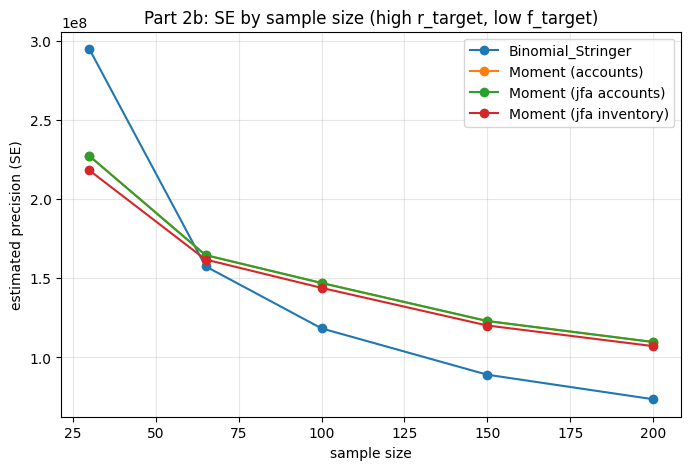

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for col in [c for c in summary_2b.columns if c.endswith("_SE")]:
    ax.plot(summary_2b.index, summary_2b[col], marker="o", label=col.replace("_SE", ""))
ax.set_xlabel("sample size")
ax.set_ylabel("estimated precision (SE)")
ax.set_title("Part 2b: SE by sample size (high r_target, low f_target)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Notes for interpretation

- `_SE` columns are the estimated precision each bound returns; `_ULE` columns are the resulting upper error limit (`EE_pred + SE`, adjusted for the certainty stratum where applicable).
- "Moment (accounts)" and "Moment (jfa accounts)" are two independent implementations of the same formula (this project's original port, and a fresh port from jfa's source) — they should match to floating-point precision in every table above; that agreement is itself a check on both implementations, not a finding about the method.
- "Moment (jfa inventory)" differs from both only in the hypothetical-tainting term (`tstar`).
- Part 2a's second code cell prints the actual `tstar` values for a real sample in that scenario, including the maximum real taint observed, so you can see directly how each formula's `tstar` compares to what's physically possible (a taint of 1) and to the real data.
- No summary verdict is given here on purpose — read the tables/plot above and draw your own conclusions about which bound performs better in which regime.

In [17]:
pop_hi = import_population(BV_pop="BV_15pct_above_SI", f_target=0.5, corr_target=0.10, r_target=0.04)
BV_hi, N_hi, EE_hi = pop_hi["BV"].sum(), len(pop_hi), pop_hi["E"].sum()

rows_2b = []
for sample_size in [30, 65, 100, 150, 200]:
    df = run_many(pop_hi, N_hi, BV_hi, EE_hi, sample_size=sample_size, iterations=150, seed=2000)
    se_cols = [c for c in df.columns if c.endswith("_SE")]
    means = df[se_cols].mean()
    means["sample_size"] = sample_size
    means["mean_erroneous_items"] = df["number_errors"].mean()
    rows_2b.append(means)

summary_2b = pd.DataFrame(rows_2b).set_index("sample_size")
summary_2b

,Binomial_Stringer_SE,Moment (accounts)_SE,Moment (jfa accounts)_SE,Moment (jfa inventory)_SE,mean_erroneous_items
sample_size,,,,,
30,"290,626,753","218,044,233","218,044,233","148,431,266",17
65,"152,268,954","136,313,240","136,313,240","104,329,613",31
100,"108,876,899","110,543,640","110,543,640","92,019,688",43
150,"79,295,914","87,353,232","87,353,232","75,428,180",64
200,"64,520,856","76,005,846","76,005,846","67,436,281",85


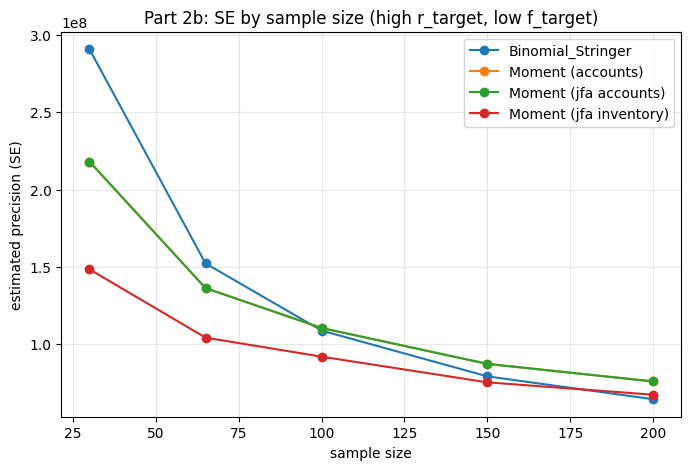

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for col in [c for c in summary_2b.columns if c.endswith("_SE")]:
    ax.plot(summary_2b.index, summary_2b[col], marker="o", label=col.replace("_SE", ""))
ax.set_xlabel("sample size")
ax.set_ylabel("estimated precision (SE)")
ax.set_title("Part 2b: SE by sample size (high r_target, low f_target)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()